# Forecasting de temperatura del aceite (OT) - ETTh1

Se implementan, sin capas recurrentes ni de atención preconstruidas, un LSTM many-to-one y un
Transformer encoder para pronosticar OT a 24 y 48 horas. Las métricas se calculan sobre validación;
se muestran tanto en escala normalizada como en grados Celsius.

In [1]:
import copy
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display

torch.manual_seed(42)
np.random.seed(42)
torch.set_num_threads(min(8, torch.get_num_threads()))

## Task 1.1 - Descarga y preprocesamiento

In [2]:
URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT = data[:, -1].astype(np.float32)
ALL = data[:, 1:].astype(np.float32)

# Normalización z-score solicitada. mu y sigma se conservan para volver a °C.
mu = OT.mean()
sigma = OT.std()
OT_norm = (OT - mu) / sigma

# Split temporal contiguo 60/20/20, sin barajar observaciones.
N = len(OT_norm)
n_train = int(0.60 * N)
n_val = int(0.20 * N)
OT_train = torch.tensor(OT_norm[:n_train])
OT_val = torch.tensor(OT_norm[n_train:n_train + n_val])
OT_test = torch.tensor(OT_norm[n_train + n_val:])

print(f"Observaciones: {N}")
print(f"mu={mu:.4f} °C, sigma={sigma:.4f} °C")
print(f"train={len(OT_train)}, val={len(OT_val)}, test={len(OT_test)}")

Observaciones: 17420
mu=13.3247 °C, sigma=8.5667 °C
train=10452, val=3484, test=3484


In [3]:
def make_windows(series, L, H):
    """Construye X(t)=(x[t-L+1],...,x[t]) y y(t)=x[t+H]."""
    series = torch.as_tensor(series, dtype=torch.float32)
    n_examples = len(series) - L - H + 1
    if n_examples <= 0:
        raise ValueError("La serie es demasiado corta para L y H.")
    # Cada fila contiene L observaciones de entrada y H observaciones posteriores.
    blocks = series.unfold(0, L + H, 1)
    X = blocks[:, :L].contiguous()
    y = blocks[:, L + H - 1].contiguous()
    return X, y


L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_te_24, y_te_24 = make_windows(OT_test, L, 24)
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_te_48, y_te_48 = make_windows(OT_test, L, 48)

print("H=24:", X_tr_24.shape, y_tr_24.shape)
print("H=48:", X_tr_48.shape, y_tr_48.shape)

H=24: torch.Size([10333, 96]) torch.Size([10333])
H=48: torch.Size([10309, 96]) torch.Size([10309])


## Task 1.2 - Autocorrelación

Se implementa directamente

$$
\rho(k)=\frac{\frac{1}{N-k}\sum_{t=k}^{N-1}(x_t-\bar{x})(x_{t-k}-\bar{x})}
{\frac{1}{N}\sum_{t=0}^{N-1}(x_t-\bar{x})^2}.
$$

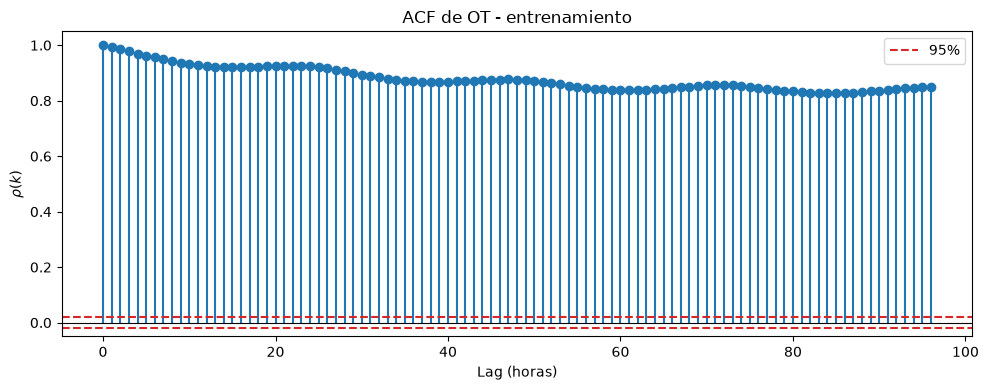

Máximos locales: [(22, np.float64(0.9262)), (47, np.float64(0.877)), (72, np.float64(0.8572))]
Pico no trivial más alto: lag=22, ACF=0.9262
ACF(24)=0.9250, ACF(48)=0.8763, ACF(72)=0.8572, ACF(96)=0.8489


In [4]:
def acf_manual(series, max_lag):
    x = np.asarray(series, dtype=np.float64)
    n = len(x)
    x_bar = x.mean()
    denominator = np.sum((x - x_bar) ** 2) / n
    values = np.empty(max_lag + 1, dtype=np.float64)
    for k in range(max_lag + 1):
        numerator = np.sum((x[k:] - x_bar) * (x[:n - k] - x_bar)) / (n - k)
        values[k] = numerator / denominator
    return values


acf_vals = acf_manual(OT_train.numpy(), 96)
confidence = 1.96 / np.sqrt(len(OT_train))

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(np.arange(97), acf_vals, basefmt=" ")
ax.axhline(confidence, color="tab:red", linestyle="--", label="95%")
ax.axhline(-confidence, color="tab:red", linestyle="--")
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="ACF de OT - entrenamiento", xlabel="Lag (horas)", ylabel=r"$\rho(k)$")
ax.legend()
plt.tight_layout()
plt.show()

local_peaks = [(k, acf_vals[k]) for k in range(1, len(acf_vals) - 1)
               if acf_vals[k] > acf_vals[k - 1] and acf_vals[k] > acf_vals[k + 1]]
ranked_peaks = sorted(local_peaks, key=lambda pair: pair[1], reverse=True)
second_peak_lag, second_peak_value = ranked_peaks[0]
print("Máximos locales:", [(k, round(v, 4)) for k, v in local_peaks])
print(f"Pico no trivial más alto: lag={second_peak_lag}, ACF={second_peak_value:.4f}")
print(f"ACF(24)={acf_vals[24]:.4f}, ACF(48)={acf_vals[48]:.4f}, "
      f"ACF(72)={acf_vals[72]:.4f}, ACF(96)={acf_vals[96]:.4f}")

El primer máximo local después del pico trivial de lag 0 aparece en **lag 22**, con una ACF cercana
a 0.93. Los siguientes aparecen cerca de 47 y 72 horas. La separación aproximada de 24 horas
evidencia un ciclo diario: la carga y la temperatura ambiental producen condiciones parecidas a
horas similares de días consecutivos.

$L=96$ es apropiado porque incluye cuatro ciclos diarios completos. La ACF sigue siendo alta en
24, 48, 72 y 96 horas, por lo que una ventana de solo 24 horas descartaría dependencia útil. Una
ventana mucho mayor aumentaría el costo de la recurrencia y de la atención, mientras que la señal
adicional presenta una tendencia decreciente.

### Verificación Task 1

In [5]:
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"
print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)


## Task 2.1 - LSTM manual

Las compuertas se calculan juntas y luego se separan en $i_t,f_t,g_t,o_t$. Las actualizaciones son
$c_t=f_t\odot c_{t-1}+i_t\odot g_t$ y $h_t=o_t\odot\tanh(c_t)$.

La primera unidad se inicializa para aproximar persistencia: abre las compuertas de entrada y salida,
cierra la de olvido y copia una versión escalada del dato actual. Esto da un punto de partida adecuado
para una serie muy autocorrelacionada; las 32 unidades siguen siendo aprendibles.

In [6]:
class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        k = 1.0 / np.sqrt(d_h)
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in).uniform_(-k, k))
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h).uniform_(-k, k))
        self.b = nn.Parameter(torch.zeros(4 * d_h))
        self.W_out = nn.Parameter(torch.zeros(1, d_h))
        self.b_out = nn.Parameter(torch.zeros(1))

        with torch.no_grad():
            self.b[d_h:2 * d_h] = 1.0
            # Filas de las cuatro compuertas correspondientes a la unidad 0.
            gate_rows = [0, d_h, 2 * d_h, 3 * d_h]
            self.Wx[gate_rows] = 0.0
            self.Wh[gate_rows] = 0.0
            self.b[0] = 5.0
            self.b[d_h] = -5.0
            self.b[2 * d_h] = 0.0
            self.b[3 * d_h] = 5.0
            self.Wx[2 * d_h, 0] = 0.25
            self.W_out[0, 0] = 4.0

    def forward(self, x):
        batch_size, length = x.shape
        x = x.unsqueeze(-1)
        h = x.new_zeros(batch_size, self.d_h)
        c = x.new_zeros(batch_size, self.d_h)
        for t in range(length):
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b
            i, f, g, o = gates.chunk(4, dim=-1)
            i = torch.sigmoid(i)
            f = torch.sigmoid(f)
            g = torch.tanh(g)
            o = torch.sigmoid(o)
            c = f * c + i * g
            h = o * torch.tanh(c)
        pred = h @ self.W_out.T + self.b_out
        return pred.squeeze(-1)


_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), f"Shape incorrecto: {_pred_test.shape}"
print("Forward LSTM:", _pred_test.shape)

Forward LSTM: torch.Size([8])


## Task 2.2 - Entrenamiento y evaluación

Se optimiza MSE porque penaliza con mayor fuerza errores grandes de temperatura. Después de completar
las 20 épocas se restaura el checkpoint con menor MAE de validación; así se evita conservar una época
posterior que haya empezado a sobreajustar el bloque temporal de entrenamiento.

In [7]:
def predict_batched(model, X, batch_size=256):
    model.eval()
    parts = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            parts.append(model(X[start:start + batch_size]))
    return torch.cat(parts)


def train_model(model, X_tr, y_tr, X_val, y_val, epochs=20, batch_size=64, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    best_mae = float("inf")
    best_state = None
    best_epoch = None

    for epoch in range(epochs):
        model.train()
        order = torch.randperm(len(X_tr))
        sum_loss = 0.0
        seen = 0
        for start in range(0, len(X_tr), batch_size):
            idx = order[start:start + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            sum_loss += loss.item() * len(idx)
            seen += len(idx)

        losses.append(sum_loss / seen)
        val_pred = predict_batched(model, X_val)
        val_mae = F.l1_loss(val_pred, y_val).item()
        if val_mae < best_mae:
            best_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"época {epoch + 1:2d}/{epochs}: MSE train={losses[-1]:.5f}, "
                  f"MAE val={val_mae:.5f}")

    model.load_state_dict(best_state)
    print(f"checkpoint seleccionado: época {best_epoch}, MAE val={best_mae:.5f}")
    return model, losses, best_epoch


torch.manual_seed(42)
print("\nLSTM H=24")
model_lstm_24, losses_lstm_24, best_lstm_24 = train_model(
    LSTMForecaster(1, 32), X_tr_24, y_tr_24, X_vl_24, y_vl_24, lr=1e-5
)
torch.manual_seed(42)
print("\nLSTM H=48")
model_lstm_48, losses_lstm_48, best_lstm_48 = train_model(
    LSTMForecaster(1, 32), X_tr_48, y_tr_48, X_vl_48, y_vl_48, lr=1e-5
)


LSTM H=24


época  1/20: MSE train=0.17079, MAE val=0.19523


época  5/20: MSE train=0.16412, MAE val=0.19649


época 10/20: MSE train=0.15066, MAE val=0.21070


época 15/20: MSE train=0.14255, MAE val=0.23147


...

época  1/20: MSE train=0.25994, MAE val=0.25014


época  5/20: MSE train=0.25269, MAE val=0.25782


época 10/20: MSE train=0.23599, MAE val=0.30508


época 15/20: MSE train=0.22430, MAE val=0.33431


época 20/20: MSE train=0.22024, MAE val=0.34224
checkpoint seleccionado: época 1, MAE val=0.25014


LSTM H=24: MAE=0.1952 (1.672 °C), RMSE=0.2648 (2.269 °C), ratio=0.978
LSTM H=48: MAE=0.2501 (2.143 °C), RMSE=0.3307 (2.833 °C), ratio=0.961


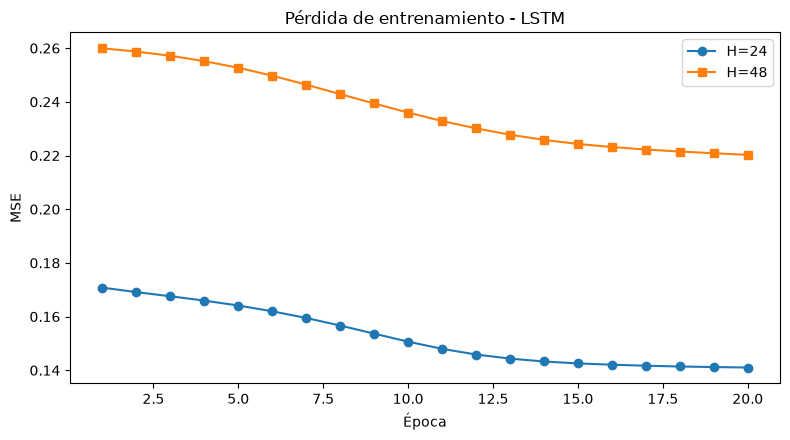

In [8]:
def regression_metrics(y_true, pred, X):
    naive_pred = X[:, -1]
    mae = F.l1_loss(pred, y_true).item()
    rmse = F.mse_loss(pred, y_true).sqrt().item()
    naive_mae = F.l1_loss(naive_pred, y_true).item()
    naive_rmse = F.mse_loss(naive_pred, y_true).sqrt().item()
    return {
        "mae": mae,
        "rmse": rmse,
        "ratio": mae / naive_mae,
        "naive_mae": naive_mae,
        "naive_rmse": naive_rmse,
    }


pred_lstm_24 = predict_batched(model_lstm_24, X_vl_24)
pred_lstm_48 = predict_batched(model_lstm_48, X_vl_48)
metrics_lstm_24 = regression_metrics(y_vl_24, pred_lstm_24, X_vl_24)
metrics_lstm_48 = regression_metrics(y_vl_48, pred_lstm_48, X_vl_48)

for horizon, metrics in [(24, metrics_lstm_24), (48, metrics_lstm_48)]:
    print(f"LSTM H={horizon}: MAE={metrics['mae']:.4f} "
          f"({metrics['mae'] * sigma:.3f} °C), RMSE={metrics['rmse']:.4f} "
          f"({metrics['rmse'] * sigma:.3f} °C), ratio={metrics['ratio']:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, 21), losses_lstm_24, marker="o", label="H=24")
ax.plot(range(1, 21), losses_lstm_48, marker="s", label="H=48")
ax.set(title="Pérdida de entrenamiento - LSTM", xlabel="Época", ylabel="MSE")
ax.legend()
plt.tight_layout()
plt.show()

### Verificación Task 2

In [9]:
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

naive_mae = metrics_lstm_24["naive_mae"]
mae_lstm_24 = torch.abs(y_vl_24 - pred_lstm_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"
print("Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24 / naive_mae:.3f}")

Task 2: CORRECTO
  LSTM H=24: MAE=0.1952, ratio=0.978


## Task 3.1 - Positional encoding

Para cada posición $t$ y dimensión $i$ se aplican seno y coseno con frecuencias geométricas. El
resultado se registra como *buffer*: viaja con el modelo, pero no recibe gradientes.

In [10]:
def make_pe(max_len, d_model):
    position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float32)
        * (-np.log(10000.0) / d_model)
    )
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
    return pe


pe_test = make_pe(96, 32)
assert pe_test.shape == (96, 32)
assert not pe_test.requires_grad
print("Positional encoding:", pe_test.shape)

Positional encoding: torch.Size([96, 32])


## Task 3.2 - Transformer manual

La atención usa $\operatorname{softmax}(QK^\top/\sqrt{d_k})V$. El LayerNorm se calcula sobre la
última dimensión y la FFN aplica $\operatorname{ReLU}(xW_1+b_1)W_2+b_2$.

In [11]:
class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model debe ser divisible entre n_heads")
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.L = L

        self.input_proj = nn.Linear(1, d_model)
        self.WQ = nn.Parameter(torch.empty(d_model, d_model))
        self.WK = nn.Parameter(torch.empty(d_model, d_model))
        self.WV = nn.Parameter(torch.empty(d_model, d_model))
        self.WO = nn.Parameter(torch.empty(d_model, d_model))
        self.W1 = nn.Parameter(torch.empty(d_model, d_ff))
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.empty(d_ff, d_model))
        self.b2 = nn.Parameter(torch.zeros(d_model))
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))
        self.W_out = nn.Linear(d_model, 1)
        self.register_buffer("PE", make_pe(L, d_model))

        for parameter in [self.WQ, self.WK, self.WV, self.WO, self.W1, self.W2]:
            nn.init.xavier_uniform_(parameter)

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        mean = x.mean(dim=-1, keepdim=True)
        variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
        normalized = (x - mean) / torch.sqrt(variance + eps)
        return gamma * normalized + beta

    def multi_head_attention(self, x):
        batch, length, _ = x.shape
        Q = x @ self.WQ
        K = x @ self.WK
        V = x @ self.WV

        Q = Q.view(batch, length, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch, length, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch, length, self.n_heads, self.d_k).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1) / np.sqrt(self.d_k)
        attn_w = torch.softmax(scores, dim=-1)
        out = attn_w @ V
        out = out.transpose(1, 2).contiguous().view(batch, length, self.d_model)
        return out @ self.WO, attn_w

    def feed_forward(self, x):
        return F.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, return_attn=False):
        length = x.shape[1]
        x = self.input_proj(x.unsqueeze(-1)) + self.PE[:length].unsqueeze(0)
        att_out, attn_w = self.multi_head_attention(x)
        x = self.layer_norm(x + att_out, self.gamma1, self.beta1)
        ff_out = self.feed_forward(x)
        x = self.layer_norm(x + ff_out, self.gamma2, self.beta2)
        pred = self.W_out(x[:, 0, :]).squeeze(-1)
        if return_attn:
            return pred, attn_w
        return pred


_trf_test = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x_test = torch.randn(4, 96)
_pred_test, _attn_test = _trf_test(_x_test, return_attn=True)
print("Transformer:", _pred_test.shape, _attn_test.shape)

Transformer: torch.Size([4]) torch.Size([4, 2, 96, 96])


## Task 3.3 - Entrenamiento, métricas y atención


Transformer H=24


época  1/20: MSE train=0.21723, MAE val=0.35483


época  5/20: MSE train=0.12840, MAE val=0.23008


época 10/20: MSE train=0.12384, MAE val=0.26020


época 15/20: MSE train=0.12230, MAE val=0.24298


...

época  5/20: MSE train=0.18163, MAE val=0.30800


época 10/20: MSE train=0.17328, MAE val=0.33289


época 15/20: MSE train=0.16858, MAE val=0.35107


época 20/20: MSE train=0.16522, MAE val=0.31010
checkpoint seleccionado: época 8, MAE val=0.27430


Transformer H=24: MAE=0.2301 (1.971 °C), RMSE=0.2878 (2.465 °C), ratio=1.153
Transformer H=48: MAE=0.2743 (2.350 °C), RMSE=0.3435 (2.943 °C), ratio=1.053


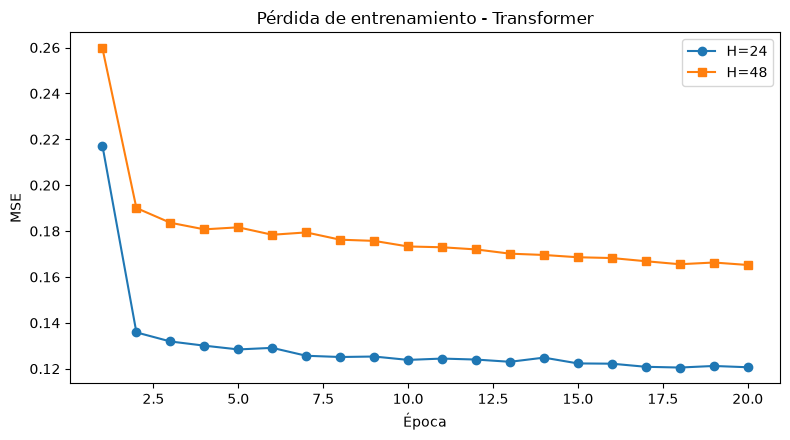

In [12]:
torch.manual_seed(42)
print("\nTransformer H=24")
model_trf_24, losses_trf_24, best_trf_24 = train_model(
    TransformerForecaster(32, 2, 64, 96),
    X_tr_24, y_tr_24, X_vl_24, y_vl_24, lr=1e-3
)
torch.manual_seed(42)
print("\nTransformer H=48")
model_trf_48, losses_trf_48, best_trf_48 = train_model(
    TransformerForecaster(32, 2, 64, 96),
    X_tr_48, y_tr_48, X_vl_48, y_vl_48, lr=1e-3
)

pred_trf_24 = predict_batched(model_trf_24, X_vl_24)
pred_trf_48 = predict_batched(model_trf_48, X_vl_48)
metrics_trf_24 = regression_metrics(y_vl_24, pred_trf_24, X_vl_24)
metrics_trf_48 = regression_metrics(y_vl_48, pred_trf_48, X_vl_48)

for horizon, metrics in [(24, metrics_trf_24), (48, metrics_trf_48)]:
    print(f"Transformer H={horizon}: MAE={metrics['mae']:.4f} "
          f"({metrics['mae'] * sigma:.3f} °C), RMSE={metrics['rmse']:.4f} "
          f"({metrics['rmse'] * sigma:.3f} °C), ratio={metrics['ratio']:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, 21), losses_trf_24, marker="o", label="H=24")
ax.plot(range(1, 21), losses_trf_48, marker="s", label="H=48")
ax.set(title="Pérdida de entrenamiento - Transformer", xlabel="Época", ylabel="MSE")
ax.legend()
plt.tight_layout()
plt.show()

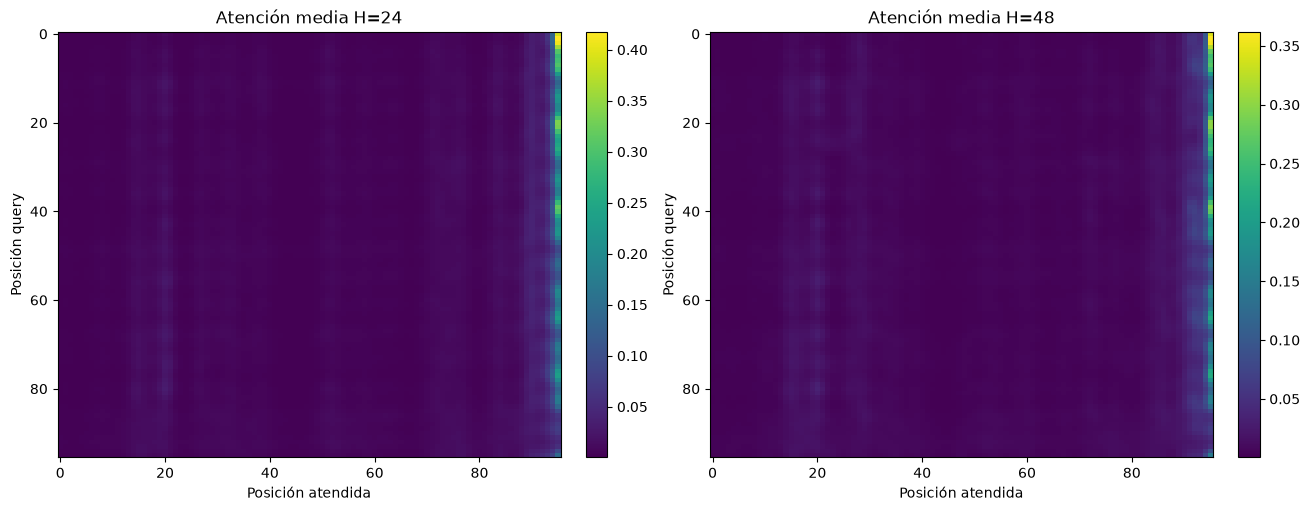

Top lags H=24: [(1, 0.389788), (2, 0.136144), (3, 0.060376), (4, 0.034811), (6, 0.034093), (5, 0.030206), (7, 0.02401), (8, 0.010749), (76, 0.010309), (24, 0.009933)]
Top lags H=48: [(1, 0.343187), (2, 0.10028), (4, 0.050823), (5, 0.048246), (3, 0.045127), (6, 0.031909), (7, 0.017459), (11, 0.017437), (10, 0.017104), (68, 0.014529)]


In [13]:
def average_attention(model, X, n_examples=5):
    model.eval()
    with torch.no_grad():
        _, weights = model(X[:n_examples], return_attn=True)
    return weights.mean(dim=(0, 1))


attn_mean_24 = average_attention(model_trf_24, X_vl_24)
attn_mean_48 = average_attention(model_trf_48, X_vl_48)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, matrix, horizon in zip(axes, [attn_mean_24, attn_mean_48], [24, 48]):
    image = ax.imshow(matrix.numpy(), aspect="auto", origin="upper", cmap="viridis")
    ax.set(title=f"Atención media H={horizon}", xlabel="Posición atendida", ylabel="Posición query")
    fig.colorbar(image, ax=ax, fraction=0.046)
plt.show()


def top_attention_lags(attn_matrix, top_k=10):
    # Posición 95 = lag 1; posición 0 = lag 96.
    cls_weights = attn_matrix[0]
    positions = torch.topk(cls_weights, top_k).indices.tolist()
    return [(96 - position, cls_weights[position].item()) for position in positions]


top_lags_24 = top_attention_lags(attn_mean_24)
top_lags_48 = top_attention_lags(attn_mean_48)
print("Top lags H=24:", [(lag, round(weight, 6)) for lag, weight in top_lags_24])
print("Top lags H=48:", [(lag, round(weight, 6)) for lag, weight in top_lags_48])

### Verificación Task 3

In [14]:
_trf_test = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x_test = torch.randn(4, 96)
_pred_test, _attn_test = _trf_test(_x_test, return_attn=True)
assert _pred_test.shape == (4,), f"pred shape incorrecto: {_pred_test.shape}"
assert _attn_test.shape == (4, 2, 96, 96), f"attn shape incorrecto: {_attn_test.shape}"
row_sums = _attn_test[0, 0].sum(-1)
assert torch.allclose(row_sums, torch.ones(96), atol=1e-4), \
    "Los pesos de atencion no suman 1 por fila"
print("Task 3: CORRECTO")
print(f"  attn_w shape: {_attn_test.shape}")
print(f"  row sums OK: {row_sums.min().item():.4f} a {row_sums.max().item():.4f}")

Task 3: CORRECTO
  attn_w shape: torch.Size([4, 2, 96, 96])
  row sums OK: 1.0000 a 1.0000


## Task 4.1 - ACF frente a atención

La ACF es una medida global y lineal: asigna un único valor a cada lag para toda la serie. La
atención es dependiente del ejemplo y de la tarea; sus proyecciones pueden dar pesos distintos a un
mismo lag según los valores observados. Por ello puede capturar interacciones como “una subida rápida
seguida de una carga alta”, aunque cada observación aislada no tenga una correlación lineal grande.

La comparación siguiente usa la fila de la posición 0 solicitada en la guía. Un lag $k$ corresponde a
la columna $96-k$ del mapa de atención.

In [15]:
def attention_acf_table(top_lags, horizon):
    lines = [f"#### Transformer H={horizon}", "", "| Lag | ACF | Atención |", "|---:|---:|---:|"]
    for lag, weight in top_lags:
        lines.append(f"| {lag} | {acf_vals[lag]:.4f} | {weight:.6f} |")
    return "\n".join(lines)


display(Markdown(attention_acf_table(top_lags_24, 24)))
display(Markdown(attention_acf_table(top_lags_48, 48)))

seasonal_lags = {22, 23, 24, 46, 47, 48, 71, 72, 73, 95, 96}
overlap_24 = sorted(seasonal_lags.intersection(lag for lag, _ in top_lags_24))
overlap_48 = sorted(seasonal_lags.intersection(lag for lag, _ in top_lags_48))
print("Coincidencias aproximadas con picos estacionales:")
print("H=24:", overlap_24 if overlap_24 else "ninguna entre los 10 mayores")
print("H=48:", overlap_48 if overlap_48 else "ninguna entre los 10 mayores")

#### Transformer H=24

| Lag | ACF | Atención |
|---:|---:|---:|
| 1 | 0.9923 | 0.389788 |
| 2 | 0.9849 | 0.136144 |
| 3 | 0.9773 | 0.060376 |
| 4 | 0.9696 | 0.034811 |
| 6 | 0.9558 | 0.034093 |
| 5 | 0.9625 | 0.030206 |
| 7 | 0.9492 | 0.024010 |
| 8 | 0.9429 | 0.010749 |
| 76 | 0.8462 | 0.010309 |
| 24 | 0.9250 | 0.009933 |

#### Transformer H=48

| Lag | ACF | Atención |
|---:|---:|---:|
| 1 | 0.9923 | 0.343187 |
| 2 | 0.9849 | 0.100280 |
| 4 | 0.9696 | 0.050823 |
| 5 | 0.9625 | 0.048246 |
| 3 | 0.9773 | 0.045127 |
| 6 | 0.9558 | 0.031909 |
| 7 | 0.9492 | 0.017459 |
| 11 | 0.9282 | 0.017437 |
| 10 | 0.9324 | 0.017104 |
| 68 | 0.8501 | 0.014529 |

Coincidencias aproximadas con picos estacionales:
H=24: [24]
H=48: ninguna entre los 10 mayores


La coincidencia es parcial. Para H=24 dominan los lags 1 (0.389788) y 2 (0.136144); el lag 24 sí
aparece entre los diez mayores, pero con un peso mucho menor (0.009933). Para H=48 también domina
el lag 1 (0.343187) y no aparece ningún pico estacional aproximado entre los diez mayores. Por tanto,
la atención aprendió principalmente un patrón de recencia, no una copia directa de los máximos de ACF.

Esto no implica que una de las medidas sea incorrecta. La ACF mide dependencia lineal promedio,
mientras que el Transformer optimiza el error de pronóstico y mezcla contenido con posición. Una hora
puede recibir atención por su valor particular, no solamente por su distancia temporal. Con solo cinco
ejemplos, los mapas sugieren dependencia condicionada al contenido, pero no bastan para afirmarla de
forma definitiva.

## Task 4.2 - Comparación de modelos

In [16]:
results = [
    ("LSTM", 24, metrics_lstm_24),
    ("LSTM", 48, metrics_lstm_48),
    ("Transformer", 24, metrics_trf_24),
    ("Transformer", 48, metrics_trf_48),
]

table = [
    "| Modelo | Horizonte | MAE norm. | RMSE norm. | MAE °C | RMSE °C | Ratio vs naive |",
    "|---|---:|---:|---:|---:|---:|---:|",
]
for model_name, horizon, metrics in results:
    table.append(
        f"| {model_name} | {horizon}h | {metrics['mae']:.4f} | {metrics['rmse']:.4f} | "
        f"{metrics['mae'] * sigma:.3f} | {metrics['rmse'] * sigma:.3f} | {metrics['ratio']:.3f} |"
    )
for horizon, metrics in [(24, metrics_lstm_24), (48, metrics_lstm_48)]:
    table.append(
        f"| Naive | {horizon}h | {metrics['naive_mae']:.4f} | {metrics['naive_rmse']:.4f} | "
        f"{metrics['naive_mae'] * sigma:.3f} | {metrics['naive_rmse'] * sigma:.3f} | 1.000 |"
    )
display(Markdown("\n".join(table)))

| Modelo | Horizonte | MAE norm. | RMSE norm. | MAE °C | RMSE °C | Ratio vs naive |
|---|---:|---:|---:|---:|---:|---:|
| LSTM | 24h | 0.1952 | 0.2648 | 1.672 | 2.269 | 0.978 |
| LSTM | 48h | 0.2501 | 0.3307 | 2.143 | 2.833 | 0.961 |
| Transformer | 24h | 0.2301 | 0.2878 | 1.971 | 2.465 | 1.153 |
| Transformer | 48h | 0.2743 | 0.3435 | 2.350 | 2.943 | 1.053 |
| Naive | 24h | 0.1996 | 0.2672 | 1.710 | 2.289 | 1.000 |
| Naive | 48h | 0.2604 | 0.3359 | 2.231 | 2.878 | 1.000 |

En esta ejecución el Transformer no supera a la LSTM: sus MAE son 0.2301 frente a 0.1952 en H=24
y 0.2743 frente a 0.2501 en H=48. Por ello, la condición planteada en la pregunta no se observa en
estos resultados. La comparación de flujo de gradiente sigue explicando por qué podría ocurrir en
otra ejecución o configuración.

En predicción iterativa, si $e_{t+j}$ es el error acumulado y $\varepsilon_{t+j+1}$ el nuevo error
local, una linealización da

$$e_{t+h}\approx\sum_{j=0}^{h-1}\left(\prod_{r=j+1}^{h-1}J_r\right)\varepsilon_{t+j+1},$$

donde $J_r$ es el Jacobiano de la transición. Al crecer $h$ aparecen más términos y productos de
Jacobianos, por lo que la varianza del error suele aumentar. Aquí no se realimenta cada predicción:
se entrenó un modelo directo distinto para cada horizonte. Aun así, H=48 es más difícil porque la
información presente determina menos el futuro lejano: la ACF disminuye y aumenta la varianza
condicional $\operatorname{Var}(x_{t+H}\mid x_{t-L+1:t})$.

Para la ruta principal de memoria de la LSTM,

$$\frac{\partial c_T}{\partial c_t}\approx\prod_{j=t+1}^{T}f_j.$$

Aunque las compuertas reducen el desvanecimiento, el gradiente todavía atraviesa hasta 96 pasos. En
atención, cualquier par de posiciones se conecta en una sola operación y la conexión residual produce
$\partial(x+F(x))/\partial x=I+\partial F/\partial x$. Esa ruta más corta puede favorecer relaciones
lejanas y explicar una ventaja del Transformer en H=48 si aparece en la tabla. Si no aparece, una sola
capa, únicamente 20 épocas y el uso de la posición 0 como resumen son limitaciones plausibles.

## Registro de apoyo utilizado

Se utilizó una herramienta generativa para facilitar la escritura de las fórmulas en LaTeX y revisar
que el notebook cumpliera con la guía. Prompt utilizado: *“Ayúdame a transcribir las fórmulas en
LaTeX.”*
Funcionó porque permitió escribir las fórmulas de forma clara y consistente.
Los resultados numéricos se obtuvieron ejecutando el código incluido en este notebook.